# Data Immersion & Wrangling

## 1. Data Access & Familiarization


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/laptop_scrap_data.csv')

# Display the first 5 rows to understand the data structure
display(df.head())

# Display basic information about the DataFrame, including data types and non-null values
df.info()

,Company,TypeName,Inches,ScreenResolution,Cpu,Gpu,OpSys,TouchScreen,Ips,X_res,...,ppi,Dedicated_Gpu,Ram_GB,Weight_kg,SSD,HHD,Storage_Type,Total_Storage_GB,Storage_Category,Price
0,MSI,MSI Prestige 16 AI+,16.0,2880 x 1800,Intel Core Ultra X7 358H,Intel Arc B390,Windows,0.0,0.0,2880.0,...,212.26,1.0,64.0,1.59,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2728.8
1,MSI,MSI Prestige 16 AI+,16.0,2880 x 1800,Intel Core Ultra 9 386H,Intel Graphics (4-Cores),Windows,0.0,0.0,2880.0,...,212.26,0.0,64.0,1.59,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2528.8
2,ASUS,ASUS Vivobook S16,16.0,1920 x 1200,AMD Ryzen AI 5 330,AMD Radeon 820M,Windows,0.0,0.0,1920.0,...,141.51,1.0,24.0,1.70,4000.0,0.0,SSD Only,4000.0,Very High (> 2TB),2428.8
3,Toshiba,Dynabook X series,13.3,1920 x 1200,Intel Core i5-1350P,Intel Iris Xe Graphics G7 (80EU),Windows,1.0,1.0,1920.0,...,170.24,0.0,16.0,0.93,512.0,0.0,SSD Only,512.0,Standard (512GB-1TB),1390.2
4,Lenovo,"Lenovo Legion 5a (15"", Gen 11, 15AGP11)",15.3,2560 x 1600,AMD Ryzen AI 9 465,NVIDIA GeForce RTX 5060 (Laptop),Windows,0.0,0.0,2560.0,...,197.31,1.0,32.0,1.87,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2067.8


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1563 entries, 0 to 1562
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1560 non-null   object 
 1   TypeName          1560 non-null   object 
 2   Inches            1560 non-null   float64
 3   ScreenResolution  1560 non-null   object 
 4   Cpu               1560 non-null   object 
 5   Gpu               1560 non-null   object 
 6   OpSys             1560 non-null   object 
 7   TouchScreen       1560 non-null   float64
 8   Ips               1560 non-null   float64
 9   X_res             1560 non-null   float64
 10  Y_res             1560 non-null   float64
 11  ppi               1560 non-null   float64
 12  Dedicated_Gpu     1560 non-null   float64
 13  Ram_GB            1560 non-null   float64
 14  Weight_kg         1560 non-null   float64
 15  SSD               1560 non-null   float64
 16  HHD               1560 non-null   float64


### Data Dictionary
Let's create a preliminary data dictionary by listing columns, their data types, and a brief description. This will be updated as we understand the data better.

In [ ]:
data_dictionary = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes,
    'Description': ['' for _ in df.columns] # Placeholder for descriptions
})

# Manually add descriptions based on initial understanding (this would be refined)
data_dictionary.loc[data_dictionary['Column Name'] == 'Brand', 'Description'] = 'Brand of the laptop'
data_dictionary.loc[data_dictionary['Column Name'] == 'Model', 'Description'] = 'Model name of the laptop'
data_dictionary.loc[data_dictionary['Column Name'] == 'Processor', 'Description'] = 'Type and generation of the CPU'
data_dictionary.loc[data_dictionary['Column Name'] == 'RAM', 'Description'] = 'Amount of RAM in GB'
data_dictionary.loc[data_dictionary['Column Name'] == 'Storage', 'Description'] = 'Type and size of storage (e.g., SSD, HDD)'
data_dictionary.loc[data_dictionary['Column Name'] == 'Display', 'Description'] = 'Screen size and resolution'
data_dictionary.loc[data_dictionary['Column Name'] == 'GPU', 'Description'] = 'Graphics Processing Unit'
data_dictionary.loc[data_dictionary['Column Name'] == 'Operating System', 'Description'] = 'Pre-installed operating system'
data_dictionary.loc[data_dictionary['Column Name'] == 'Price', 'Description'] = 'Price of the laptop (currency to be confirmed)'
data_dictionary.loc[data_dictionary['Column Name'] == 'Rating', 'Description'] = 'User rating (if available)'
data_dictionary.loc[data_dictionary['Column Name'] == 'Reviews', 'Description'] = 'Number of reviews'

display(data_dictionary)

,Column Name,Data Type,Description
Company,Company,object,
TypeName,TypeName,object,
Inches,Inches,float64,
ScreenResolution,ScreenResolution,object,
Cpu,Cpu,object,
Gpu,Gpu,object,
OpSys,OpSys,object,
TouchScreen,TouchScreen,float64,
Ips,Ips,float64,
X_res,X_res,float64,


## 2. Data Quality Assessment
Let's identify critical issues such as missing values, duplicates, and inconsistent formatting.

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

display(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

print(f"\nTotal number of rows: {len(df)}")

,Missing Count,Missing Percentage (%)
Company,3,0.191939
TypeName,3,0.191939
Inches,3,0.191939
ScreenResolution,3,0.191939
Cpu,3,0.191939
Gpu,3,0.191939
OpSys,3,0.191939
TouchScreen,3,0.191939
Ips,3,0.191939
X_res,3,0.191939



Total number of rows: 1563


In [ ]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("Displaying first 5 duplicate rows:")
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head())

Number of duplicate rows: 2
Displaying first 5 duplicate rows:


,Company,TypeName,Inches,ScreenResolution,Cpu,Gpu,OpSys,TouchScreen,Ips,X_res,...,ppi,Dedicated_Gpu,Ram_GB,Weight_kg,SSD,HHD,Storage_Type,Total_Storage_GB,Storage_Category,Price
1560,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1561,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Inconsistent Formatting and Outliers (Initial Look)
Let's examine unique values for categorical columns and descriptive statistics for numerical columns to spot inconsistencies or outliers.

In [ ]:
# Examine unique values for categorical columns
for column in df.select_dtypes(include='object').columns:
    print(f"\nUnique values for '{column}':")
    print(df[column].value_counts().head(10)) # Display top 10 unique values
    if df[column].nunique() > 10:
        print(f"...and {df[column].nunique() - 10} more unique values. Total unique: {df[column].nunique()}")

# Examine descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df.describe())


Unique values for 'Company':
Company
HP           468
Lenovo       411
ASUS         221
Dell         154
Acer         112
MSI           82
Gigabyte      24
Apple         22
Microsoft     20
Samsung       18
Name: count, dtype: int64
...and 8 more unique values. Total unique: 18

Unique values for 'TypeName':
TypeName
HP 15                 106
Lenovo IdeaPad 1       47
HP OMEN 16             39
ASUS Vivobook 14       34
HP 17                  34
HP 14                  31
Lenovo LOQ 15          28
HP Victus 15           26
Dell 15                22
HP OmniBook X Flip     17
Name: count, dtype: int64
...and 445 more unique values. Total unique: 455

Unique values for 'ScreenResolution':
ScreenResolution
Full HD (1080p)          619
1920 x 1200              467
2560 x 1600              184
HD (720p, 768p, 900p)    109
2880 x 1800               72
3840 x 2400               17
2880 x 1920                8
2560 x 1600)               8
2048 x 1280                7
1920 x 1280                7

,Inches,TouchScreen,Ips,X_res,Y_res,ppi,Dedicated_Gpu,Ram_GB,Weight_kg,SSD,HHD,Total_Storage_GB,Price
count,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000
mean,15.311859,0.726282,0.715385,2059.143590,1235.560256,157.689654,0.604487,29.324359,1.789615,1411.446154,5.025641,1416.471795,1947.008051
std,1.128081,0.446009,0.451376,431.366919,301.650510,36.177101,0.489117,22.203963,0.488822,1374.868914,24.185182,1369.910037,693.184352
min,7.000000,0.000000,0.000000,1280.000000,720.000000,84.890000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,305.990000
25%,14.000000,0.000000,0.000000,1920.000000,1080.000000,141.210000,0.000000,16.000000,1.460000,512.000000,0.000000,512.000000,1496.800000
50%,15.600000,1.000000,1.000000,1920.000000,1200.000000,141.510000,1.000000,24.000000,1.700000,1000.000000,0.000000,1000.000000,1807.800000
75%,16.000000,1.000000,1.000000,1920.000000,1200.000000,161.730000,1.000000,32.000000,2.050000,2000.000000,0.000000,2000.000000,2227.800000
max,18.000000,1.000000,1.000000,3840.000000,2400.000000,323.450000,1.000000,192.000000,4.120000,12000.000000,128.000000,12000.000000,7488.800000


## 3. Data Cleaning & Transformation

### Handling Missing Values and Duplicate Rows
As observed, there are 3 rows with missing values across all columns, and these also account for the duplicate rows. Since these represent a very small fraction of the dataset, we will drop them.

In [ ]:
# Drop rows with any missing values
df_cleaned = df.dropna().copy()

# Re-check for missing values after dropping
print("Missing values after dropping NaN rows:")
display(df_cleaned.isnull().sum().sum())

# Re-check for duplicate rows after dropping NaN rows
duplicate_rows_after_cleaning = df_cleaned.duplicated().sum()
print(f"\nNumber of duplicate rows after dropping NaN rows: {duplicate_rows_after_cleaning}")

# If there are still duplicates (should not be, but as a safeguard), drop them.
if duplicate_rows_after_cleaning > 0:
    df_cleaned.drop_duplicates(inplace=True)
    print(f"Dropped {duplicate_rows_after_cleaning} remaining duplicate rows.")

print(f"\nNew number of rows after cleaning: {len(df_cleaned)}")

Missing values after dropping NaN rows:


np.int64(0)


Number of duplicate rows after dropping NaN rows: 0

New number of rows after cleaning: 1560


### Standardizing 'ScreenResolution' Column
We noticed an inconsistency in 'ScreenResolution', specifically '2560 x 1600' and '2560 x 1600)'. We will standardize these entries.

In [ ]:
# Standardize 'ScreenResolution' entries
df_cleaned['ScreenResolution'] = df_cleaned['ScreenResolution'].str.replace(')', '', regex=False)

# Verify the change
print("Unique values for 'ScreenResolution' after standardization:")
print(df_cleaned['ScreenResolution'].value_counts().head())

Unique values for 'ScreenResolution' after standardization:
ScreenResolution
Full HD (1080p          619
1920 x 1200             467
2560 x 1600             192
HD (720p, 768p, 900p    109
2880 x 1800              72
Name: count, dtype: int64


### Reviewing Data Types and Values after Cleaning
Let's re-examine the data types and descriptive statistics to ensure the cleaning steps had the desired effect and to identify any further cleaning needs.

In [ ]:
print("DataFrame Info after cleaning:")
df_cleaned.info()

print("\nDescriptive statistics for numerical columns after cleaning:")
display(df_cleaned.describe())

DataFrame Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 1560 entries, 0 to 1559
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1560 non-null   object 
 1   TypeName          1560 non-null   object 
 2   Inches            1560 non-null   float64
 3   ScreenResolution  1560 non-null   object 
 4   Cpu               1560 non-null   object 
 5   Gpu               1560 non-null   object 
 6   OpSys             1560 non-null   object 
 7   TouchScreen       1560 non-null   float64
 8   Ips               1560 non-null   float64
 9   X_res             1560 non-null   float64
 10  Y_res             1560 non-null   float64
 11  ppi               1560 non-null   float64
 12  Dedicated_Gpu     1560 non-null   float64
 13  Ram_GB            1560 non-null   float64
 14  Weight_kg         1560 non-null   float64
 15  SSD               1560 non-null   float64
 16  HHD             

,Inches,TouchScreen,Ips,X_res,Y_res,ppi,Dedicated_Gpu,Ram_GB,Weight_kg,SSD,HHD,Total_Storage_GB,Price
count,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000
mean,15.311859,0.726282,0.715385,2059.143590,1235.560256,157.689654,0.604487,29.324359,1.789615,1411.446154,5.025641,1416.471795,1947.008051
std,1.128081,0.446009,0.451376,431.366919,301.650510,36.177101,0.489117,22.203963,0.488822,1374.868914,24.185182,1369.910037,693.184352
min,7.000000,0.000000,0.000000,1280.000000,720.000000,84.890000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,305.990000
25%,14.000000,0.000000,0.000000,1920.000000,1080.000000,141.210000,0.000000,16.000000,1.460000,512.000000,0.000000,512.000000,1496.800000
50%,15.600000,1.000000,1.000000,1920.000000,1200.000000,141.510000,1.000000,24.000000,1.700000,1000.000000,0.000000,1000.000000,1807.800000
75%,16.000000,1.000000,1.000000,1920.000000,1200.000000,161.730000,1.000000,32.000000,2.050000,2000.000000,0.000000,2000.000000,2227.800000
max,18.000000,1.000000,1.000000,3840.000000,2400.000000,323.450000,1.000000,192.000000,4.120000,12000.000000,128.000000,12000.000000,7488.800000


### Outlier Detection (Numerical Columns)
Let's use the Interquartile Range (IQR) method to identify potential outliers in key numerical columns and visualize their distributions to decide on handling strategies.


Column 'Inches': 2 outliers detected (0.13% of data).


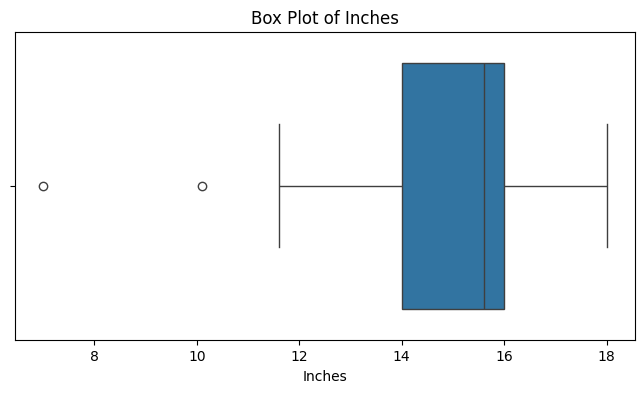


Column 'Ram_GB': 248 outliers detected (15.90% of data).


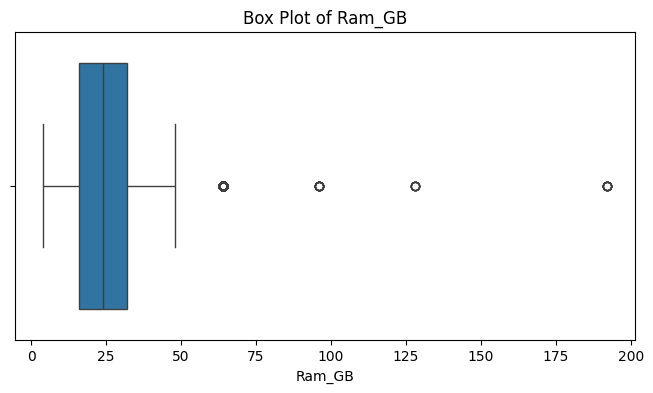


Column 'Weight_kg': 48 outliers detected (3.08% of data).


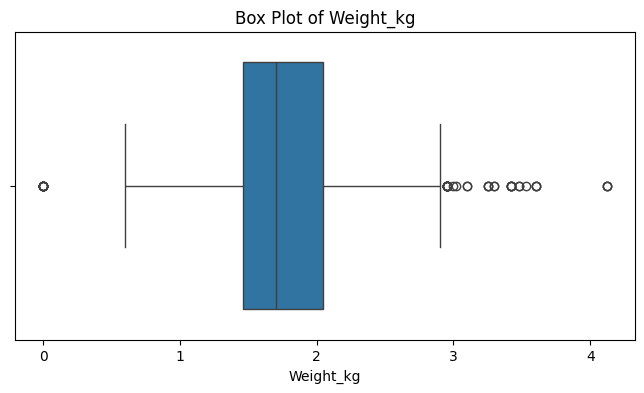


Column 'SSD': 27 outliers detected (1.73% of data).


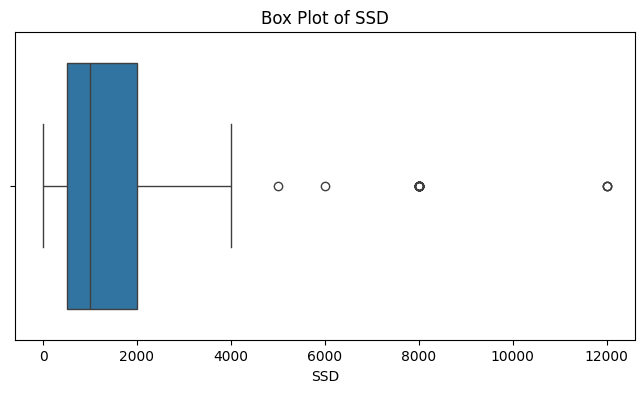


Column 'HHD': 68 outliers detected (4.36% of data).


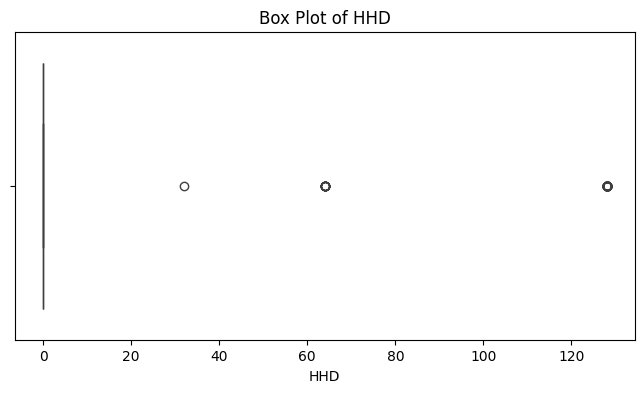


Column 'Total_Storage_GB': 27 outliers detected (1.73% of data).


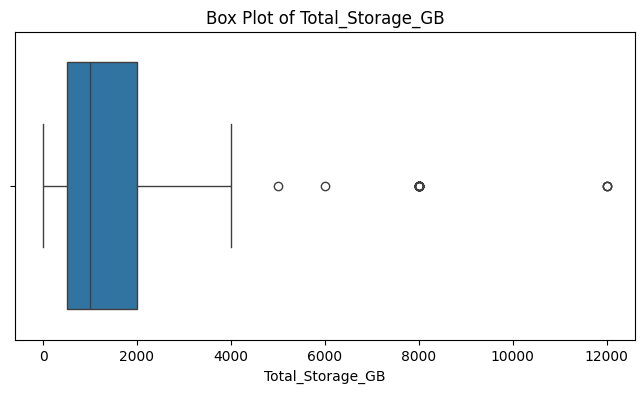


Column 'Price': 58 outliers detected (3.72% of data).


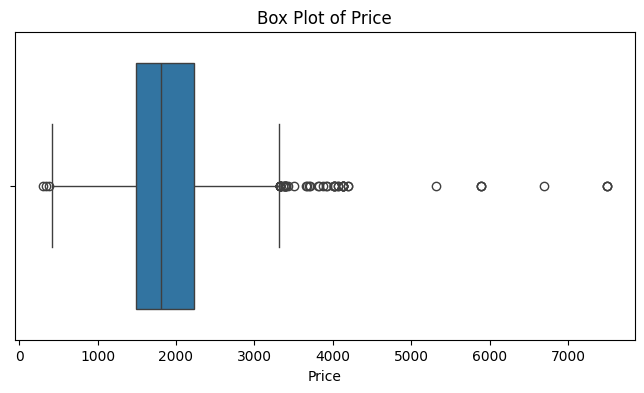

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Columns to check for outliers
numerical_cols = ['Inches', 'Ram_GB', 'Weight_kg', 'SSD', 'HHD', 'Total_Storage_GB', 'Price']

for col in numerical_cols:
    outliers = detect_outliers_iqr(df_cleaned, col)
    print(f"\nColumn '{col}': {len(outliers)} outliers detected ({(len(outliers)/len(df_cleaned))*100:.2f}% of data).")

    # Visualize with box plot
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_cleaned[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

# For now, we'll keep outliers but note their presence. Further analysis might require specific handling.

### Further Categorical Data Cleaning and Consolidation
Some categorical columns might have similar entries that can be grouped to reduce cardinality and improve consistency (e.g., variations in CPU or GPU names, or 'Company' names). Let's re-examine `Company`, `Cpu`, `Gpu`, and `TypeName` for such opportunities.

In [ ]:
# Check value counts for potential consolidation in 'Company'
print("\nValue counts for 'Company':")
print(df_cleaned['Company'].value_counts())

# Example: Consolidating 'ScreenResolution' variations that might still exist
# For instance, if 'Full HD (1080p)' and 'Full HD (1920x1080)' were present, we'd standardize.
# We've already handled the ')' issue, but this is a general check.
print("\nUnique values for 'ScreenResolution' (top 5 after previous cleaning):")
print(df_cleaned['ScreenResolution'].value_counts().head())

# For 'Cpu' and 'Gpu', a more advanced text processing might be needed,
# but for now, we'll just inspect the diversity.
print("\nNumber of unique CPU entries:", df_cleaned['Cpu'].nunique())
print("\nNumber of unique GPU entries:", df_cleaned['Gpu'].nunique())

# Given the high cardinality of 'Cpu' and 'Gpu', a detailed cleaning might involve
# extracting features like brand (Intel, AMD, Nvidia), series (Core i5, Ryzen 7, RTX), etc.
# For this task, we will consider the existing 'Cpu' and 'Gpu' as distinct for now,
# but note that further feature engineering could simplify these.


Value counts for 'Company':
Company
HP           468
Lenovo       411
ASUS         221
Dell         154
Acer         112
MSI           82
Gigabyte      24
Apple         22
Microsoft     20
Samsung       18
Alienware      8
Huawei         5
LG             5
Dynabook       3
Fujitsu        2
HONOR          2
AORUS          2
Toshiba        1
Name: count, dtype: int64

Unique values for 'ScreenResolution' (top 5 after previous cleaning):
ScreenResolution
Full HD (1080p          619
1920 x 1200             467
2560 x 1600             192
HD (720p, 768p, 900p    109
2880 x 1800              72
Name: count, dtype: int64

Number of unique CPU entries: 230

Number of unique GPU entries: 134


### Feature Engineering
Let's extract the CPU brand from the 'Cpu' column to create a new categorical feature, and simplify the 'ScreenResolution' into categories like 'HD', 'FHD', 'QHD', 'UHD'.

In [ ]:
# Feature Engineering: Extract CPU Brand
def get_cpu_brand(cpu_string):
    if 'Intel' in cpu_string:
        return 'Intel'
    elif 'AMD' in cpu_string:
        return 'AMD'
    elif 'Apple' in cpu_string:
        return 'Apple'
    else:
        return 'Other'

df_cleaned['Cpu_Brand'] = df_cleaned['Cpu'].apply(get_cpu_brand)
print("\nValue counts for 'Cpu_Brand':")
print(df_cleaned['Cpu_Brand'].value_counts())

# Feature Engineering: Categorize Screen Resolution
def categorize_screen_resolution(resolution_string):
    if '3840' in resolution_string or '4K' in resolution_string:
        return 'UHD'
    elif '2560' in resolution_string or 'QHD' in resolution_string:
        return 'QHD'
    elif '1920' in resolution_string or 'Full HD' in resolution_string:
        return 'FHD'
    elif '1366' in resolution_string or '1280' in resolution_string or 'HD' in resolution_string:
        return 'HD'
    else:
        return 'Other'

df_cleaned['Resolution_Category'] = df_cleaned['ScreenResolution'].apply(categorize_screen_resolution)
print("\nValue counts for 'Resolution_Category':")
print(df_cleaned['Resolution_Category'].value_counts())



Value counts for 'Cpu_Brand':
Cpu_Brand
Intel    1075
AMD       427
Other      38
Apple      20
Name: count, dtype: int64

Value counts for 'Resolution_Category':
Resolution_Category
FHD      1101
QHD       204
Other     118
HD        117
UHD        20
Name: count, dtype: int64


### Final Review and Output
Let's review the final `df_cleaned` DataFrame's information and head to ensure all transformations are applied correctly. This dataset is now ready for analysis.

In [ ]:
print("Final DataFrame Info:")
df_cleaned.info()

print("\nFirst 5 rows of the cleaned and transformed dataset:")
display(df_cleaned.head())

# Optionally, save the cleaned dataset
# df_cleaned.to_csv('laptop_data_cleaned.csv', index=False)
# print("Cleaned dataset saved to 'laptop_data_cleaned.csv'")

Final DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1560 entries, 0 to 1559
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1560 non-null   object 
 1   TypeName             1560 non-null   object 
 2   Inches               1560 non-null   float64
 3   ScreenResolution     1560 non-null   object 
 4   Cpu                  1560 non-null   object 
 5   Gpu                  1560 non-null   object 
 6   OpSys                1560 non-null   object 
 7   TouchScreen          1560 non-null   float64
 8   Ips                  1560 non-null   float64
 9   X_res                1560 non-null   float64
 10  Y_res                1560 non-null   float64
 11  ppi                  1560 non-null   float64
 12  Dedicated_Gpu        1560 non-null   float64
 13  Ram_GB               1560 non-null   float64
 14  Weight_kg            1560 non-null   float64
 15  SSD                  

,Company,TypeName,Inches,ScreenResolution,Cpu,Gpu,OpSys,TouchScreen,Ips,X_res,...,Ram_GB,Weight_kg,SSD,HHD,Storage_Type,Total_Storage_GB,Storage_Category,Price,Cpu_Brand,Resolution_Category
0,MSI,MSI Prestige 16 AI+,16.0,2880 x 1800,Intel Core Ultra X7 358H,Intel Arc B390,Windows,0.0,0.0,2880.0,...,64.0,1.59,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2728.8,Intel,Other
1,MSI,MSI Prestige 16 AI+,16.0,2880 x 1800,Intel Core Ultra 9 386H,Intel Graphics (4-Cores),Windows,0.0,0.0,2880.0,...,64.0,1.59,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2528.8,Intel,Other
2,ASUS,ASUS Vivobook S16,16.0,1920 x 1200,AMD Ryzen AI 5 330,AMD Radeon 820M,Windows,0.0,0.0,1920.0,...,24.0,1.70,4000.0,0.0,SSD Only,4000.0,Very High (> 2TB),2428.8,AMD,FHD
3,Toshiba,Dynabook X series,13.3,1920 x 1200,Intel Core i5-1350P,Intel Iris Xe Graphics G7 (80EU),Windows,1.0,1.0,1920.0,...,16.0,0.93,512.0,0.0,SSD Only,512.0,Standard (512GB-1TB),1390.2,Intel,FHD
4,Lenovo,"Lenovo Legion 5a (15"", Gen 11, 15AGP11)",15.3,2560 x 1600,AMD Ryzen AI 9 465,NVIDIA GeForce RTX 5060 (Laptop),Windows,0.0,0.0,2560.0,...,32.0,1.87,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2067.8,AMD,QHD


```markdown
# Laptop Data Immersion & Wrangling

This project focuses on the initial steps of data understanding, cleaning, and transformation for a dataset containing laptop specifications and prices. The goal is to prepare the data for further analysis, potentially leading to a laptop price prediction model.

## Dataset
The dataset used is `laptop_scrap_data.csv`, which contains various attributes of laptops including brand, type, screen specifications, CPU, GPU, RAM, storage, weight, operating system, and price.

## Notebook Overview

This notebook covers the following key stages of data immersion and wrangling:

### 1. Data Access & Familiarization
- Loaded the `laptop_scrap_data.csv` into a pandas DataFrame.
- Displayed the first few rows (`df.head()`) to get an initial look at the data structure.
- Examined basic information about the DataFrame (`df.info()`) to understand data types and non-null counts.

### 2. Data Dictionary
- Created a preliminary data dictionary outlining column names, their data types, and initial descriptions. This serves as a foundational reference that can be refined as understanding deepens.

### 3. Data Quality Assessment
- **Missing Values:** Identified columns with missing values and calculated their percentage. Noted that 3 rows had missing values across all columns.
- **Duplicate Rows:** Checked for and identified duplicate entries in the dataset. Found 2 duplicate rows, which were also part of the missing value entries.
- **Inconsistent Formatting and Outliers (Initial Look):** Inspected unique values for categorical columns (`Company`, `TypeName`, `ScreenResolution`, `Cpu`, `Gpu`, `OpSys`, `Storage_Type`, `Storage_Category`) and descriptive statistics for numerical columns to spot initial inconsistencies or potential outliers.

### 4. Data Cleaning & Transformation
- **Handling Missing Values and Duplicate Rows:** Dropped the 3 rows with missing values, which also resolved the duplicate row issue, as they represented a small fraction of the data.
- **Standardizing 'ScreenResolution' Column:** Corrected inconsistencies in the `ScreenResolution` column (e.g., `'2560 x 1600)'` was standardized to `'2560 x 1600'`).
- **Reviewing Data Types and Values:** Re-examined the DataFrame information and descriptive statistics to confirm the cleaning steps were effective.

### 5. Outlier Detection (Numerical Columns)
- Used the Interquartile Range (IQR) method to detect potential outliers in numerical columns such as `Inches`, `Ram_GB`, `Weight_kg`, `SSD`, `HHD`, `Total_Storage_GB`, and `Price`.
- Visualized outlier distributions using box plots to understand their presence, noting that no action was taken on outliers at this stage, but their presence is documented.

### 6. Further Categorical Data Cleaning and Consolidation
- Inspected value counts for highly cardinal categorical columns like `Company`, `Cpu`, `Gpu`, and `TypeName` to identify opportunities for further consolidation or feature extraction.
- Noted that `Cpu` and `Gpu` have high cardinality, suggesting potential for more advanced text processing and feature engineering in later stages.

### 7. Feature Engineering
- **CPU Brand Extraction:** Created a new categorical feature `Cpu_Brand` by extracting the brand (Intel, AMD, Apple, Other) from the `Cpu` column.
- **Screen Resolution Categorization:** Created a new categorical feature `Resolution_Category` by grouping `ScreenResolution` into simplified categories (`HD`, `FHD`, `QHD`, `UHD`, `Other`).

### 8. Final Review and Output
- Reviewed the final `df_cleaned` DataFrame's information and head to ensure all transformations were applied correctly.
- The `df_cleaned` DataFrame is now prepared for further exploratory data analysis, visualization, and potentially model building.

## Tools and Libraries
- **pandas:** For data manipulation and analysis.
- **numpy:** For numerical operations.
- **matplotlib.pyplot:** For basic plotting and visualization.
- **seaborn:** For advanced statistical data visualization.

```